# Probability Review for Machine Learning
**Reference:** CS229 Probability Review (Kolter & Do, Stanford)

8 core topics. One section per concept. Each section: definition → formula → code → ML connection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

---
## 1. Random Variables

A **random variable** maps outcomes of a random process to numbers.

- **Discrete:** countable outcomes — e.g. die roll X ∈ {1,2,3,4,5,6}
- **Continuous:** any value in a range — e.g. pixel intensity X ∈ [0, 255]

**Probability Mass Function (discrete):**
$$P(X = x)$$

**Probability Density Function (continuous):**
$$p(x) \text{ such that } \int p(x)\,dx = 1$$

**In ML:** Model output is a random variable. For a 10-class classifier:
$$P(Y = \text{cat} \mid \text{image})$$

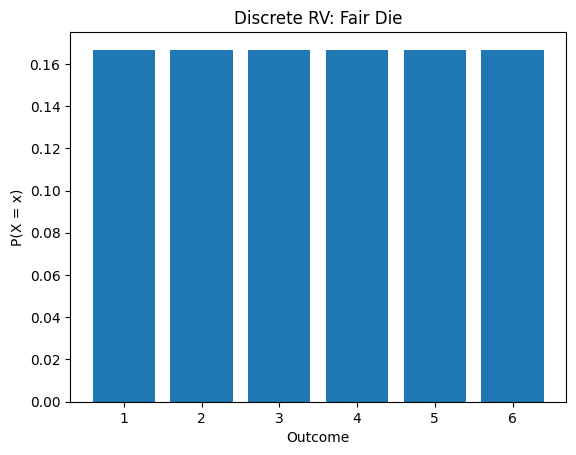

Sum of probabilities: 0.9999999999999999


In [2]:
# Discrete random variable: die roll
outcomes = np.arange(1, 7)
probabilities = np.ones(6) / 6

plt.bar(outcomes, probabilities)
plt.xlabel('Outcome')
plt.ylabel('P(X = x)')
plt.title('Discrete RV: Fair Die')
plt.show()

print(f"Sum of probabilities: {probabilities.sum()}")  # Must equal 1

---
## 2. Probability Distributions

A distribution describes how probability is spread across outcomes.

### Gaussian (Normal)
$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

### Bernoulli (binary outcome)
$$P(X=1) = p, \quad P(X=0) = 1-p$$

### Categorical (multi-class)
$$P(X=k) = p_k, \quad \sum_k p_k = 1$$

**In ML:**
- Gaussian → linear regression noise assumption
- Bernoulli → binary classification output
- Categorical → softmax output for multi-class classification

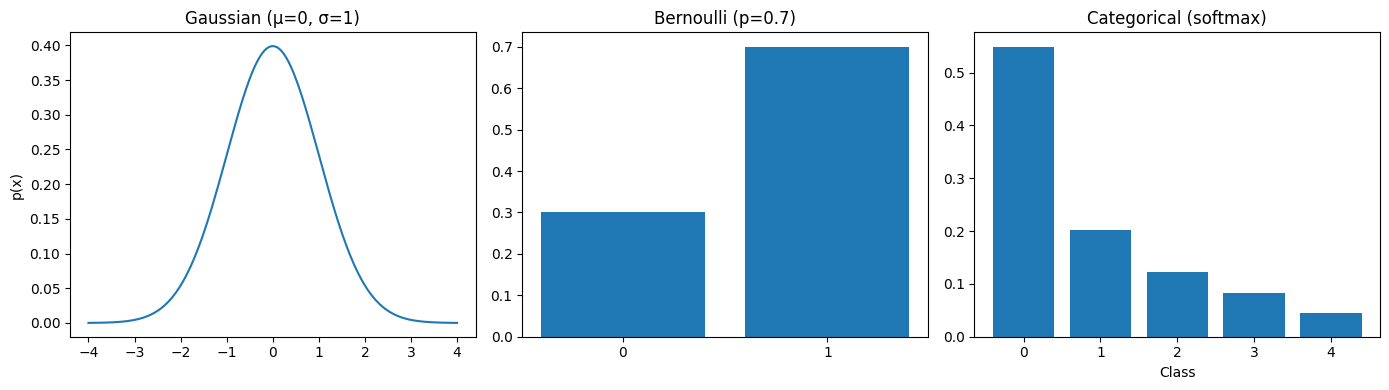

Categorical probs sum: 1.0000


In [3]:
x = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gaussian
axes[0].plot(x, stats.norm.pdf(x, 0, 1))
axes[0].set_title('Gaussian (μ=0, σ=1)')
axes[0].set_ylabel('p(x)')

# Bernoulli
p = 0.7
axes[1].bar([0, 1], [1-p, p])
axes[1].set_title(f'Bernoulli (p={p})')
axes[1].set_xticks([0, 1])

# Categorical (softmax output example)
logits = np.array([2.0, 1.0, 0.5, 0.1, -0.5])
probs = np.exp(logits) / np.exp(logits).sum()
axes[2].bar(range(5), probs)
axes[2].set_title('Categorical (softmax)')
axes[2].set_xlabel('Class')

plt.tight_layout()
plt.show()

print(f"Categorical probs sum: {probs.sum():.4f}")

---
## 3. Bayes' Theorem

$$P(A \mid B) = \frac{P(B \mid A) \cdot P(A)}{P(B)}$$

- $P(A)$ — **prior**: what you believe before seeing data
- $P(B \mid A)$ — **likelihood**: probability of data given hypothesis
- $P(A \mid B)$ — **posterior**: updated belief after seeing data
- $P(B)$ — **evidence**: normalizing constant

**In ML:** Bayesian inference, Naive Bayes classifier, probabilistic graphical models.

Training a model = updating your prior belief about weights after seeing data.

In [4]:
# Medical test example — classic Bayes
# Disease prevalence: 1% of population
# Test sensitivity: 99% (P(positive | disease))
# Test specificity: 95% (P(negative | no disease))

P_disease = 0.01
P_no_disease = 1 - P_disease
P_pos_given_disease = 0.99
P_pos_given_no_disease = 0.05  # false positive rate

# P(positive) = total evidence
P_positive = P_pos_given_disease * P_disease + P_pos_given_no_disease * P_no_disease

# Posterior: P(disease | positive test)
P_disease_given_pos = (P_pos_given_disease * P_disease) / P_positive

print(f"P(disease | positive test) = {P_disease_given_pos:.3f}")
print(f"Despite 99% accurate test, only {P_disease_given_pos*100:.1f}% chance of disease")
print(f"Why? Because disease is rare — prior dominates")

P(disease | positive test) = 0.167
Despite 99% accurate test, only 16.7% chance of disease
Why? Because disease is rare — prior dominates


---
## 4. Expectation and Variance

**Expectation** — the average value of a random variable:
$$\mathbb{E}[X] = \sum_x x \cdot P(X=x) \quad \text{(discrete)}$$
$$\mathbb{E}[X] = \int x \cdot p(x)\,dx \quad \text{(continuous)}$$

**Variance** — how spread out the values are:
$$\text{Var}(X) = \mathbb{E}[(X - \mathbb{E}[X])^2] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

**In ML:**
- Loss function = expected error over the data distribution
- Bias-variance tradeoff: high bias = wrong expectation, high variance = too sensitive to data

In [5]:
# Die roll
outcomes = np.arange(1, 7)
probs = np.ones(6) / 6

expectation = np.sum(outcomes * probs)
variance = np.sum((outcomes - expectation)**2 * probs)
std = np.sqrt(variance)

print(f"E[X] = {expectation:.2f}")
print(f"Var(X) = {variance:.2f}")
print(f"Std(X) = {std:.2f}")

# Verify with many samples
samples = np.random.choice(outcomes, size=100000, p=probs)
print(f"\nEmpirical mean (100k samples): {samples.mean():.3f}")
print(f"Empirical std: {samples.std():.3f}")

E[X] = 3.50
Var(X) = 2.92
Std(X) = 1.71

Empirical mean (100k samples): 3.503
Empirical std: 1.704


---
## 5. Joint, Marginal, Conditional Probability

**Joint:** probability of two events together
$$P(X=x, Y=y)$$

**Marginal:** probability of one variable, summed over the other
$$P(X=x) = \sum_y P(X=x, Y=y)$$

**Conditional:** probability of X given Y is known
$$P(X=x \mid Y=y) = \frac{P(X=x, Y=y)}{P(Y=y)}$$

**In ML:**
- Joint: $P(\text{image}, \text{label})$ — what generative models learn
- Conditional: $P(\text{label} \mid \text{image})$ — what discriminative models (classifiers) learn

In [6]:
# Joint distribution over two dice
joint = np.ones((6, 6)) / 36  # uniform joint

# Marginal: sum over one axis
marginal_X = joint.sum(axis=1)  # sum over Y
marginal_Y = joint.sum(axis=0)  # sum over X

print(f"Marginal P(X=1): {marginal_X[0]:.4f} — should be 1/6 = {1/6:.4f}")

# Conditional: P(X=1 | Y=3)
y_val = 2  # Y=3 (index 2)
conditional = joint[:, y_val] / marginal_Y[y_val]
print(f"P(X | Y=3): {conditional}")
print(f"Sum: {conditional.sum():.4f} — must equal 1")

Marginal P(X=1): 0.1667 — should be 1/6 = 0.1667
P(X | Y=3): [0.16666667 0.16666667 0.16666667 0.16666667 0.16666667 0.16666667]
Sum: 1.0000 — must equal 1


---
## 6. Maximum Likelihood Estimation (MLE)

Find the parameters θ that make the observed data most probable.

$$\hat{\theta}_{MLE} = \arg\max_\theta \prod_{i=1}^n p(x^{(i)};\theta)$$

In practice: maximize log-likelihood (avoids numerical underflow)

$$\hat{\theta}_{MLE} = \arg\max_\theta \sum_{i=1}^n \log p(x^{(i)};\theta)$$

**In ML:** Training a model = MLE. CrossEntropyLoss = negative log-likelihood.

Minimizing cross-entropy loss = maximizing likelihood of the correct label.

True μ: 3.0, MLE estimate: 3.0290
True σ: 1.5, MLE estimate: 1.4681
Log-likelihood at MLE: -1802.90


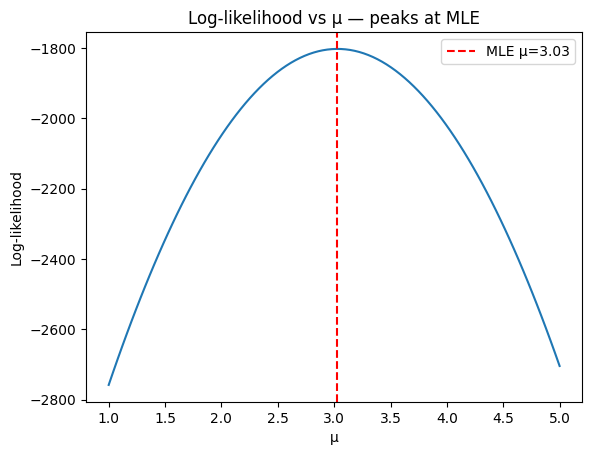

In [7]:
# MLE for Gaussian: find mu and sigma from data
np.random.seed(42)
true_mu, true_sigma = 3.0, 1.5
data = np.random.normal(true_mu, true_sigma, size=1000)

# MLE estimates for Gaussian are simply mean and std
mu_mle = data.mean()
sigma_mle = data.std()

print(f"True μ: {true_mu}, MLE estimate: {mu_mle:.4f}")
print(f"True σ: {true_sigma}, MLE estimate: {sigma_mle:.4f}")

# Log-likelihood at MLE
log_likelihood = np.sum(stats.norm.logpdf(data, mu_mle, sigma_mle))
print(f"Log-likelihood at MLE: {log_likelihood:.2f}")

# Show how log-likelihood changes with different mu
mu_range = np.linspace(1, 5, 100)
ll = [np.sum(stats.norm.logpdf(data, m, sigma_mle)) for m in mu_range]

plt.plot(mu_range, ll)
plt.axvline(mu_mle, color='red', linestyle='--', label=f'MLE μ={mu_mle:.2f}')
plt.xlabel('μ')
plt.ylabel('Log-likelihood')
plt.title('Log-likelihood vs μ — peaks at MLE')
plt.legend()
plt.show()

---
## 7. KL Divergence

Measures how different distribution Q is from reference distribution P.

$$D_{KL}(P \| Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$$

Properties:
- $D_{KL} \geq 0$ always
- $D_{KL} = 0$ only when P = Q
- **Not symmetric:** $D_{KL}(P\|Q) \neq D_{KL}(Q\|P)$

**In ML:**
- VAE loss = reconstruction loss + KL divergence
- CrossEntropy loss = H(P) + KL(P||Q) — minimizing cross-entropy = minimizing KL divergence from true distribution
- RLHF: KL penalty keeps fine-tuned model close to base model

In [8]:
# KL divergence between two discrete distributions
def kl_divergence(P, Q):
    P = np.array(P, dtype=float)
    Q = np.array(Q, dtype=float)
    return np.sum(P * np.log(P / Q))

# True label distribution (one-hot: class 2 is correct)
P_true = np.array([0.0, 0.0, 1.0, 0.0, 0.0])

# Good prediction: confident on class 2
Q_good = np.array([0.02, 0.02, 0.90, 0.03, 0.03])

# Bad prediction: spread across classes
Q_bad = np.array([0.25, 0.25, 0.25, 0.15, 0.10])

# Add small epsilon to P_true to avoid log(0)
eps = 1e-10
P_true_smooth = P_true + eps
P_true_smooth /= P_true_smooth.sum()

print(f"KL(P || Q_good) = {kl_divergence(P_true_smooth, Q_good):.4f}")
print(f"KL(P || Q_bad)  = {kl_divergence(P_true_smooth, Q_bad):.4f}")
print("Lower KL = predictions closer to truth")

KL(P || Q_good) = 0.1054
KL(P || Q_bad)  = 1.3863
Lower KL = predictions closer to truth


---
## 8. Central Limit Theorem (CLT)

The sum (or mean) of many independent random variables approaches a Gaussian distribution, regardless of the original distribution.

$$\bar{X}_n = \frac{1}{n}\sum_{i=1}^n X_i \xrightarrow{d} \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right) \text{ as } n \to \infty$$

**In ML:**
- Justifies why Gaussian noise assumptions work in practice
- Mini-batch gradient estimates are approximately Gaussian — justifies using mean gradient
- Why many real-world measurement errors are Gaussian

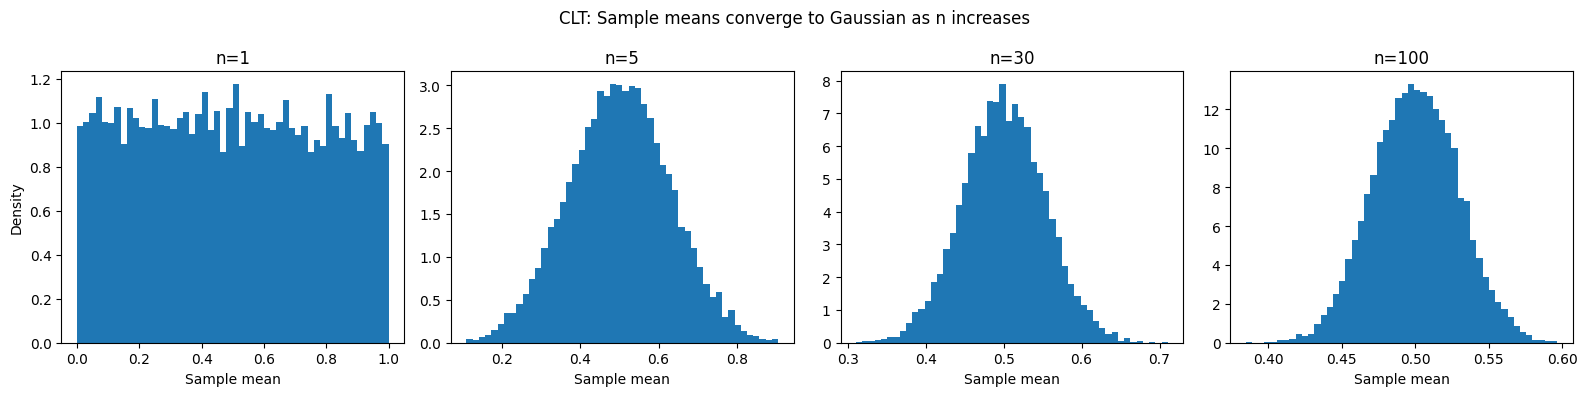

n=1: uniform shape
n=30: already looks Gaussian
n=100: clearly Gaussian


In [9]:
# CLT: sample means from a uniform distribution become Gaussian
np.random.seed(42)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
sample_sizes = [1, 5, 30, 100]

for ax, n in zip(axes, sample_sizes):
    # 10,000 experiments: each takes mean of n uniform samples
    means = [np.random.uniform(0, 1, n).mean() for _ in range(10000)]
    ax.hist(means, bins=50, density=True)
    ax.set_title(f'n={n}')
    ax.set_xlabel('Sample mean')

axes[0].set_ylabel('Density')
plt.suptitle('CLT: Sample means converge to Gaussian as n increases')
plt.tight_layout()
plt.show()

print("n=1: uniform shape")
print("n=30: already looks Gaussian")
print("n=100: clearly Gaussian")

---
## Summary

| Concept | Formula | ML Connection |
|---|---|---|
| Random Variable | $P(X=x)$ | Model output is a distribution over classes |
| Distributions | Gaussian, Bernoulli, Categorical | Loss function choice depends on output distribution |
| Bayes' Theorem | $P(A|B) = P(B|A)P(A)/P(B)$ | Posterior inference, probabilistic models |
| Expectation | $\mathbb{E}[X] = \sum x P(x)$ | Expected loss over data distribution |
| Variance | $\mathbb{E}[(X-\mu)^2]$ | Bias-variance tradeoff |
| Joint/Marginal/Conditional | $P(X,Y), P(X), P(X|Y)$ | Generative vs discriminative models |
| MLE | $\arg\max \sum \log p(x;\theta)$ | Training = maximizing likelihood |
| KL Divergence | $\sum P \log P/Q$ | VAE loss, cross-entropy, RLHF penalty |
| CLT | $\bar{X}_n \to \mathcal{N}(\mu, \sigma^2/n)$ | Justifies Gaussian assumptions, mini-batch gradients |